In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_2 import system_cfg
from single_qubit_pyscrip_v1_2.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg
print(soccfg)
print("Data save path:", system_cfg.DATA_PATH)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_691545c04b8d44e8baec1486600765ba@192.168.10.7:35077
QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelo

In [2]:
from YOKOGS200 import YOKOGS200
import pyvisa 
rm = pyvisa.ResourceManager()
yoko_connect='USB0::0x0B21::0x0039::91WB18859::INSTR'
yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()

# Qubit setting

In [36]:
# Define the qubit index
qubit_idx = 3

config={
    **system_cfg.hw_cfg,
    **system_cfg.readout_cfg,
    **system_cfg.qubit_cfg,
    **system_cfg.expt_cfg,
    **system_cfg.cool_cfg}

# YOKO

In [23]:
yoko.SetMode('current')
yokocurrent = 2*1e-3
yoko.SetCurrent(yokocurrent)
yoko.GetCurrent()

0.002

In [24]:
import scqubits as scq
def linear_map(x, src_range, target_range):
    src_min, src_max = src_range
    tgt_min, tgt_max = target_range
    return tgt_min + (x - src_min) / (src_max - src_min) * (tgt_max - tgt_min)

q1flux = (-1.1, 3.9) # mA
q4flux = (-1.775, 7.4) # mA

flux = yokocurrent*1e3
q1_nflux = linear_map(flux, q1flux, (1, 0.5))
q4_nflux = linear_map(flux, q4flux, (0.5,1))

q1 = scq.Fluxonium(EJ=3.664, EC=0.945, EL=0.586, cutoff=51, flux=q1_nflux)
q4 = scq.Fluxonium(EJ=3.469, EC=0.952, EL=0.582, cutoff=51, flux=q4_nflux)

config['qubit_freq_ge'][qubit_idx] = q1.E01()
print(f'fq1 = {q1.E01()}, at phi = {1 - q1_nflux% 1}')
print(f'fq4 = {q4.E01()}, at phi = {1 - q4_nflux% 1}')

fq1 = 3.3201704704211363, at phi = 0.31000000000000005
fq4 = 3.4532424031451336, at phi = 0.29427792915531337


# Resonator OneTone

{'Fres(GHz)': 5.7977, 'Qi': 41362, 'Ql': 345, 'absQc': 348, 'κ(MHz)': 16.82}


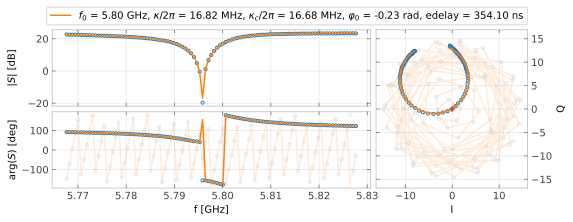

In [37]:
from single_qubit_pyscrip_v1_2.s002_res_spec_ge import Resonator_onetone

START_FREQ = config['res_freq_ge'][qubit_idx]- 30  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 30   # [MHz]

STEPS = 101


config['res_gain_ge'][qubit_idx] = 0.4
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('relax_delay', 1),
                ('cooling', False)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = onetone.run(py_avg=20, liveplot=True, solve_type='hm')
# result = onetone.plot_circle()
## update value ##
config['res_freq_ge'][qubit_idx] = round(fres[0]/1e6,4)
# onetone.saveLabber(qubit_idx, yoko_current=yokocurrent)


# Qubit Spectrum ge

Figure saved to C:\Users\QEL\Desktop\2DQ12_round2\individual\Fig\qubit_spectrum_ge.png


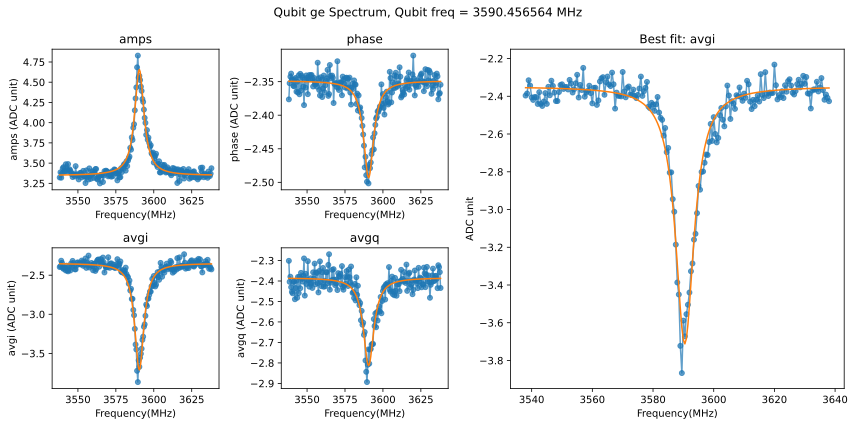

In [39]:
from single_qubit_pyscrip_v1_2.s003_qubit_spec_ge import Qubit_Twotone

cemter = 3588
SPAN = 50

START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 201 

config['nqz_qubit'] = 2

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',cemter),
                ('qubit_gain_ge', 0.3),
                # ('res_gain_ge', 0.2),
                ('qubit_length_ge', 5.0),
                ('relax_delay',1),
                ('cooling', False),
                ('qubit_ch', 2)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(20, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
# spectrum_ge.saveLabber(qubit_idx, yoko_current = yokocurrent)

# Power Rabi ge

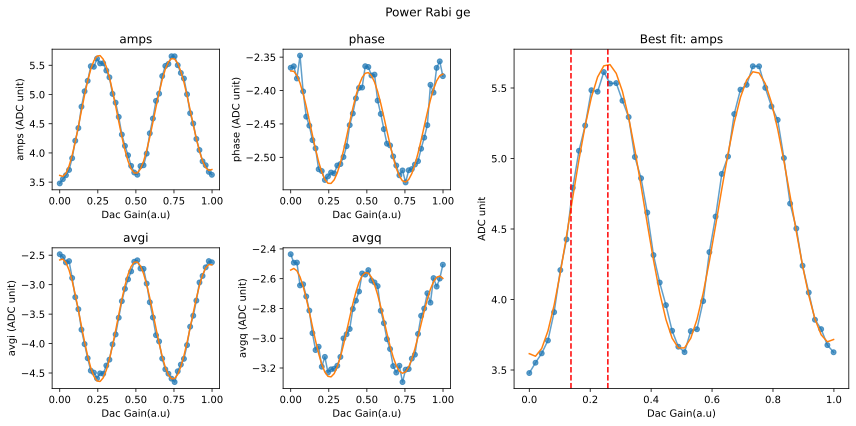

In [47]:
from single_qubit_pyscrip_v1_2.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 50

config['relax_delay'] = 50  # [us]
config["sigma"][qubit_idx] = 0.1
config['qubit_ge_pulse_style'] = 'arb'
# config['qubit_ge_pulse_style'] = 'flat_top'
# config['qubit_flat_top_length_ge'] = 0.3  # [us]
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ge',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', False),
    ('qubit_ch', 2),
    ])

prabi = Amp_Rabi(soc, soccfg, run_cfg)
config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.run(20, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx, yoko_current=yokocurrent)

# Ramsey

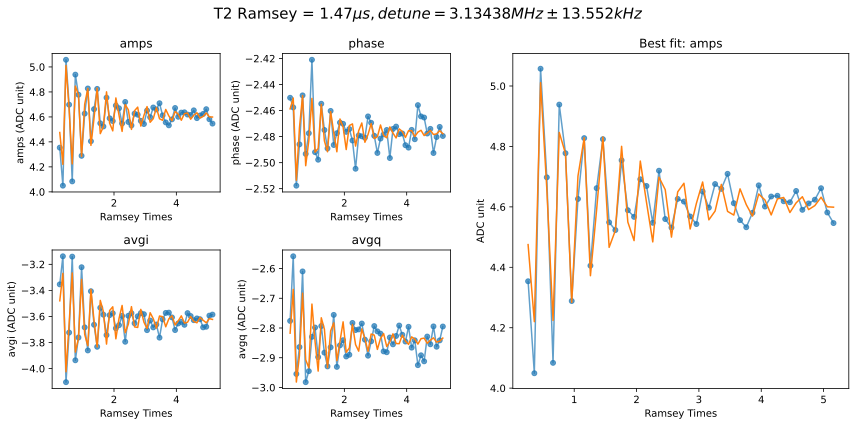

In [43]:
from single_qubit_pyscrip_v1_2.s006_Ramsey_ge import Ramsey

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 5 # [us]
STEPS = 50
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 2),
    ('cooling', False),
    ('qubit_ch', 2),

    ])

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(30, liveplot=True)
# t2r.plot()
# config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()
# t2r.saveLabber(qubit_idx, yoko_current=yokocurrent)


In [44]:
config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()

over detune 1.13438MHz


# Echo

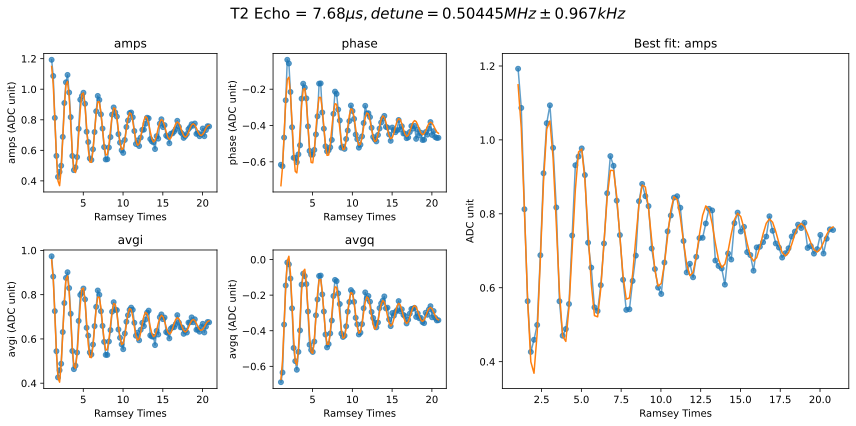

In [82]:
from single_qubit_pyscrip_v1_2.s007_SpinEcho_ge import SpinEcho

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 20  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 0.5),
    ('cooling', False),
    ('qubit_ch', 14),
    ])

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(20, liveplot=True)
# t2e.plot()
# t2e.saveLabber(qubit_idx, yoko_current=yokocurrent)

# T1

2025-07-22 16:05:11,317 - SR_Network:BlockingClient - Error: Socket operation timed out
ERROR:BlockingClient:Error: Socket operation timed out


Data save to C:\Users\QEL\Desktop\2DQ12_round2\individual\2025\07\Data_0722\s008_T1_ge_Q3_0.002mA


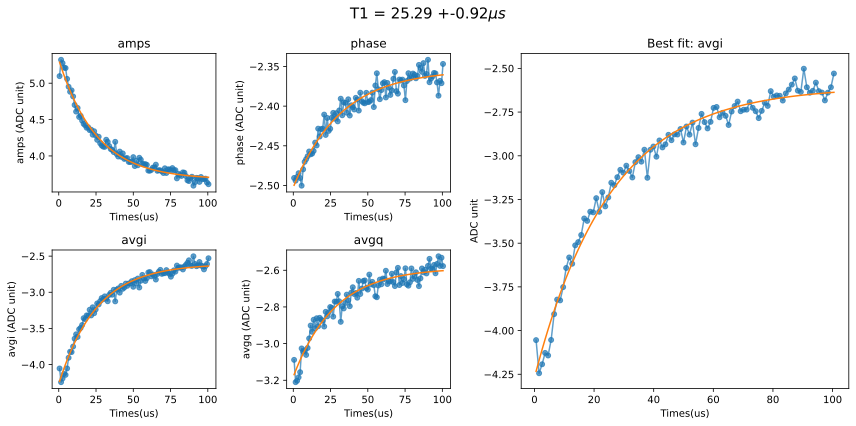

In [48]:
from single_qubit_pyscrip_v1_2.s008_T1_ge import T1

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 100),
    ('cooling', False),
    ('qubit_ch', 2),
    ])

t1 = T1(soc, soccfg, run_cfg)
t1.run(30, liveplot=True)

t1.saveLabber(qubit_idx, yoko_current=yokocurrent)

# Single shot

In [87]:
from single_qubit_pyscrip_v1_2.s000_SingleShot_prog import SingleShot_gef
run_cfg = select_config_idx(config, qubit_idx)

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT)
ssh.plot(fid_avg=True, fit=True)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

g unrotated averages:
I 1.0656502604166667 +/- 0.6680431951992767 	 Q -0.8539670572916668 +/- 0.7707854516346928 	 Amp 1.5972946281973341 +/- 0.5949050397342377
Rotated (theta=-2.816212411688834):
I -1.2827216649255042 +/- 0.7376802714139385 	 Q 0.46850330073142565 +/- 0.7044286623004593 	 Amp 1.3656025089554786 +/- 0.5949050397342377
e unrotated averages:
I 1.0516337239583333 +/- 0.6665481520759764 	 Q -0.84923828125 +/- 0.775497659658517 	 Amp 1.5864587011912648 +/- 0.5966330499504593
Rotated (theta=-2.816212411688834):
I -1.267928943163096 +/- 0.7375382745829443 	 Q 0.46850330073142576 +/- 0.7083222096595233 	 Amp 1.35171711082864 +/- 0.5966330499504593
Attempted to init fitparam 4 to -1.3028085967156726, which is out of bounds -0.6122407375551409 to 2.441603795176987. Instead init to 0.9146815288109231
Attempted to init fitparam 4 to -1.3028085967156726, which is out of bounds -0.6122407375551409 to 2.441603795176987. Instead init to 0.9146815288109231


fidelity:[0.5081] 
thressholds:[-1.3335005015672516] 
theta:-161.35708540212923

        Fidelity Matrix:
        -----------------
        | 50.260% | 49.740% |
        ----------------
        | 48.640% | 51.360% |
        -----------------
        IQ plane rotated by: -161.4°
        Threshold: -1.334e+00
        Fidelity: 50.810%
        


In [84]:
from single_qubit_pyscrip_v1_2.s000_SingleShot_ge_prog_opt import SingleShot_ge_opt
run_cfg = select_config_idx(config, qubit_idx)

SHOT = 500
ssh_opt = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh_opt.run(SHOT)
# ssh_opt.plot(fid_avg=True, fit=True)

Length loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/18 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

In [86]:
max_len, max_gain, max_freq, _ = ssh_opt.analyze()
run_cfg.update([
    ('ro_length', max_len),
    ('res_gain_ge', max_gain),
    ('res_freq_ge', max_freq),])

Analyze max fidelity:   0%|          | 0/20 [00:00<?, ?it/s]

Max fidelity: 0.1440
At length=3.700 us, gain=0.600 DAC, freq=5350.888 MHz
